# LSST Alert Packet Stamps: PSF, WCS, and Image Data

*How cutout images are stored in Rubin alert packets,  how to work with them using astropy and how to run ForcedPhotometry*

---

## Background

When the Rubin Observatory detects a transient or variable source, it broadcasts an alert packet for every new detection. Each packet bundles three postage-stamp cutouts centred on the source: the science image (the new exposure), the template image (a deep reference coadd), and the difference image. These stamps are small FITS files — typically 30×30 pixels at 0.2 arcsec/px — embedded in the alert as binary blobs.

Rubin alert stamps are serialised as `astropy.nddata.CCDData` objects. This required an astropy-side change,  adding first-class `psf` attribute support to `CCDData`. Astropy ≥ 5.2 is required to work with Rubin alerts. Together these changes mean that a science cutout from a Rubin alert packet can be fully reconstructed using pure astropy, with no LSST Science Pipelines dependency.

## FITS Extension Layout

### Science stamps 

Science and difference cutouts produced by Rubin  follow a clean three-extension layout:

| Extension | `EXTNAME` | Shape | dtype | Content |
|-----------|-----------|-------|-------|---------|
| HDU 0 | `PRIMARY` | 30×30 | float32 | Calibrated flux image (nJy), plus WCS keywords in header |
| HDU 1 | `UNCERT` | 30×30 | float32 | Per-pixel variance (nJy²) |
| HDU 2 | `PSFIMAGE` | 41×41 | float64 | PSF kernel, normalised to sum = 1 |

The extension names `UNCERT` and `PSFIMAGE` are the defaults expected by `CCDData.read()`, so no keyword arguments are needed; a bare `CCDData.read(path)` populates all three attributes automatically.

## The Three Planes

### Image

The primary HDU carries the calibrated surface brightness in **nanojanskys (nJy)**. The `BUNIT = 'nJy'` keyword is present in the header, and `CCDData.read()` stores this as `ccd.unit`. The pixel values are float32. A 30×30 stamp at 0.2 arcsec/px covers roughly 6×6 arcsec on the sky.

### Variance

The uncertainty extension stores **per-pixel variance** (σ², in nJy²). The variance plane is a per-pixel map of the statistical uncertainty (variance) associated with each science pixel in an exposure. The variance plane is built up from multiple noise sources:
* Poisson noise from the source flux itself
* Sky background shot noise
* Read noise (from the detector electronics)
* Dark current
* Flat-field / gain uncertainties (propagated during ISR)
* Covariance from resampling/warping (in coadds, neighboring pixels become correlated)

It is used in PSF fitting and model fitting (e.g., in meas_modelfit) and in the propagation of uncertainties through the pipeline. 

`CCDData` wraps this as a `VarianceUncertainty` object at `ccd.uncertainty`, and the raw numpy array is at `ccd.uncertainty.array`. Variance propagates linearly through arithmetic: when you add or subtract two `CCDData` objects, the variances add (assuming independence), and `CCDData` handles this automatically. The signal-to-noise ratio at any pixel is `image / sqrt(variance)`.

### PSF kernel

The PSF extension stores an **image-plane representation of the point spread function** sampled at the centre of the cutout. It is a 2-D array normalised to sum to unity, which preserves flux during convolution. `CCDData` exposes this as `ccd.psf`, a plain numpy array.

One important behavioural note from the astropy docs: *"The psf is set to None in the output of an arithmetic operation, no matter the inputs, and a warning message is emitted if either of the input images contain a non-None PSF."* This means that if you subtract a template from a science stamp using `ccd.subtract(ccd_tmpl)`, the resulting difference image has no PSF attached, and you must re-assign it manually (`diff.psf = ccd.psf`).

Once you have `ccd.wcs`, use `wcs.world_to_pixel_values(ra_deg, dec_deg)` to convert a sky position to pixel coordinates. Prefer this low-level call over `wcs.world_to_pixel(SkyCoord(...))` because the latter requires astropy to recognise the WCS as a celestial frame, which it sometimes fails to do for plain FITS headers, raising a confusing *"Number of world inputs does not match expected"* error.

## WCS

World coordinate system information follows the standard FITS convention, stored as keywords in the PRIMARY header: `CRPIX1/2`, `CRVAL1/2` (in decimal degrees), and a PC matrix plus `CDELT` values encoding the pixel scale and rotation.

For the 30×30 stamps with a pixel scale of 0.2 arcsec/px, the WCS describes a tangent-plane (gnomonic) projection centred close to the source.

`CCDData.read()` attempts to parse the WCS from the header and attaches the result as `ccd.wcs`, an `astropy.wcs.WCS` object. In practice the read can silently return `ccd.wcs = None` if it encounters a header it cannot parse; a safe fallback is:

if ccd.wcs is None:
    with fits.open(path) as hdul:
        ccd.wcs = WCS(hdul[0].header)

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import astropy
import astropy.units as u
from astropy.coordinates   import SkyCoord
from astropy.io            import fits
from astropy.modeling      import fitting, models
from astropy.nddata        import CCDData, VarianceUncertainty
from astropy.table         import Table
from astropy.visualization import ZScaleInterval
from astropy.wcs           import WCS

import lsst.afw.image as afwImage
import lsst.geom      as lsst_geom
from lsst.afw.geom        import makeSkyWcs
from lsst.afw.math        import FixedKernel
from lsst.meas.algorithms import KernelPsf
from lsst.pipe.tasks.measurementDriver import (
    ForcedMeasurementDriverConfig,
    ForcedMeasurementDriverTask,
)


In [2]:
print(f'astropy {astropy.__version__}  (requires >= 5.2)')

astropy 7.1.0  (requires >= 5.2)


## Define science stamp image file

In [3]:
DIA_OBJECT_ID = 313853517426065465
DATA_DIR      = Path('../../data') / str(DIA_OBJECT_ID)
SCIENCE_PATH  = DATA_DIR / f'{DIA_OBJECT_ID}_{DIA_OBJECT_ID}_science.fits'

print(f'Data dir  : {DATA_DIR}')
print(f'Stamp file: {SCIENCE_PATH.name}')


Data dir  : ../../data/313853517426065465
Stamp file: 313853517426065465_313853517426065465_science.fits


In [4]:
# ── Read detections parquet ───────────────────────────────────────────────────
parquet_path = DATA_DIR / f'{DIA_OBJECT_ID}_detections.parquet'
df_dets = pd.read_parquet(parquet_path)

# ── Find the 3 science stamp files and extract their measurement IDs ──────────
# Filename format: {OID}_{measurement_id}_{type}.fits
stamp_files = sorted(DATA_DIR.glob(f'{DIA_OBJECT_ID}_*_science.fits'))
mids = [int(f.stem.split('_')[1]) for f in stamp_files]

print(f'Found {len(stamp_files)} science stamp file(s):')
for f in stamp_files:
    print(f'  {f.name}')

# ── Filter detections to stamp measurement IDs ────────────────────────────────
df_stamps = (
    df_dets[df_dets['measurement_id'].isin(mids)]
    .set_index('measurement_id')
    .loc[mids]          # preserve order matching stamp filenames
    .copy()
)

# ── Alert-packet AB magnitude from psfFlux (nJy) ─────────────────────────────
# Same formula used throughout this notebook: m = -2.5 log10(F_nJy * 1e-9 / 3631)
pos = df_stamps['psfFlux'] > 0
df_stamps['alertMag'] = np.where(
    pos,
    -2.5 * np.log10(df_stamps['psfFlux'].clip(lower=1e-30) * 1e-9 / 3631),
    np.nan,
)
df_stamps['alertMagErr'] = np.where(
    pos,
    2.5 / np.log(10) * df_stamps['psfFluxErr'].abs() / df_stamps['psfFlux'].abs(),
    np.nan,
)

# ── Display summary ───────────────────────────────────────────────────────────
cols = ['band', 'mjd', 'ra', 'dec', 'psfFlux', 'psfFluxErr', 'alertMag', 'alertMagErr']
print()
print(df_stamps[cols].to_string(float_format='{:.6f}'.format))

# ── Set SRC_RA / SRC_DEC from the row matching SCIENCE_PATH ──────────────────
mid_key = int(SCIENCE_PATH.stem.split('_')[1])
src_row       = df_stamps.loc[mid_key]
SRC_RA        = float(src_row['ra'])
SRC_DEC       = float(src_row['dec'])
ALERT_MAG     = float(src_row['alertMag'])
ALERT_MAG_ERR = float(src_row['alertMagErr'])
ALERT_BAND    = str(src_row['band'])

print()
print(f'Active stamp     : measurement_id={mid_key}')
print(f'Source position  : RA={SRC_RA:.7f}  Dec={SRC_DEC:.7f}')
print(f'Alert PSF mag    : {ALERT_MAG:.4f} ± {ALERT_MAG_ERR:.4f}  ({ALERT_BAND}-band)')


Found 1 science stamp file(s):
  313853517426065465_313853517426065465_science.fits

                    band          mjd         ra      dec     psfFlux  psfFluxErr  alertMag  alertMagErr
measurement_id                                                                                          
313853517426065465     3 61024.245933 150.490757 2.775519 3715.872300  371.606500 22.474914     0.108579

Active stamp     : measurement_id=313853517426065465
Source position  : RA=150.4907570  Dec=2.7755190
Alert PSF mag    : 22.4749 ± 0.1086  (3-band)


## Inspect raw FITS structure

In [5]:
with fits.open(SCIENCE_PATH) as hdul:
    hdul.info()
    print()
    hdr = hdul[0].header
    for key in ('BUNIT', 'CRPIX1', 'CRPIX2', 'CRVAL1', 'CRVAL2',
                'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'):
        if key in hdr:
            print(f'  {key:8s} = {hdr[key]}')

Filename: ../../data/313853517426065465/313853517426065465_313853517426065465_science.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (30, 30)   float32   
  1  UNCERT        1 ImageHDU         9   (30, 30)   float32   
  2  PSFIMAGE      1 ImageHDU         8   (41, 41)   float64   

  BUNIT    = nJy
  CRPIX1   = 15.6679540943
  CRPIX2   = 15.611531264942
  CRVAL1   = 150.49075695269
  CRVAL2   = 2.775519012442
  PC1_1    = 5.5363514990773e-05
  PC1_2    = -4.8904140111694e-06
  PC2_1    = -4.9004059007304e-06
  PC2_2    = -5.5342557559978e-05


## Reading the Alerce Stamp as `CCDData`

In [6]:
ccd = CCDData.read(
    SCIENCE_PATH,
    hdu_uncertainty = 'UNCERT',    # default; explicit for clarity
    hdu_psf         = 'PSFIMAGE',  # default in astropy >= 5.2
)

# Fallback if WCS was not parsed
if ccd.wcs is None:
    with fits.open(SCIENCE_PATH) as hdul:
        ccd.wcs = WCS(hdul[0].header)

image    = ccd.data                     # float32 array, nJy
variance = ccd.uncertainty.array        # float32 array, nJy²
psf      = np.array(ccd.psf)           # float64 array, normalised
wcs      = ccd.wcs                     # astropy WCS object

In [7]:
print(f'data       : shape={ccd.data.shape}  dtype={ccd.data.dtype}  unit={ccd.unit}')
print(f'uncertainty: {type(ccd.uncertainty).__name__}  shape={ccd.uncertainty.array.shape}')
print(f'psf        : shape={np.array(ccd.psf).shape}  sum={np.array(ccd.psf).sum():.6f}')

data       : shape=(30, 30)  dtype=>f4  unit=nJy
uncertainty: VarianceUncertainty  shape=(30, 30)
psf        : shape=(41, 41)  sum=1.000000


### Sky-to-pixel conversion

In [8]:
x_pix, y_pix = ccd.wcs.world_to_pixel_values(SRC_RA, SRC_DEC)
print(f'Source pixel: ({x_pix:.3f}, {y_pix:.3f})')

Source pixel: (14.668, 14.612)


### Visualise image, variance, and PSF

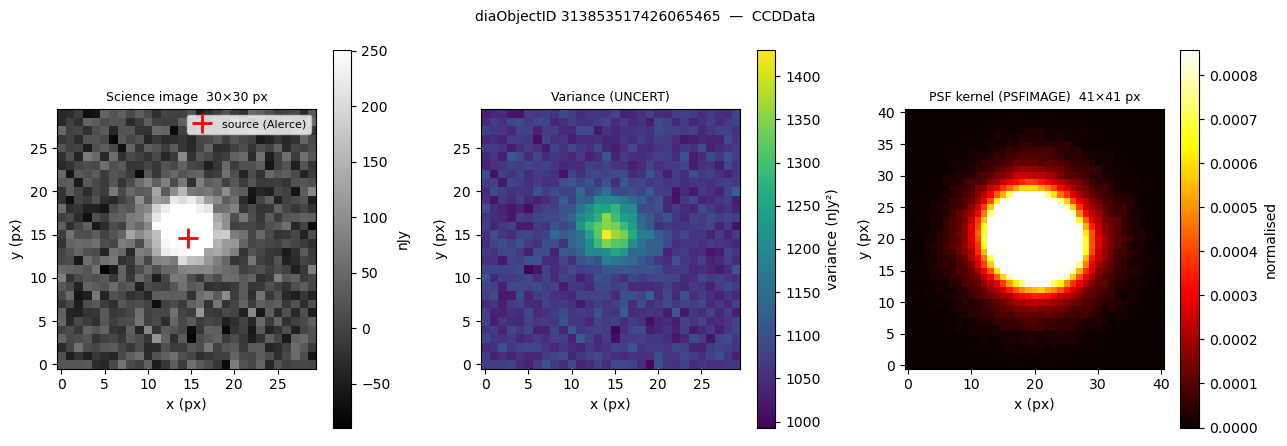

In [9]:
zscale = ZScaleInterval()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

#  Science image 
ax = axes[0]
vmin, vmax = zscale.get_limits(image)
im = ax.imshow(image, origin='lower', cmap='gray',
               vmin=vmin, vmax=vmax, interpolation='nearest')
plt.colorbar(im, ax=ax, label=str(ccd.unit))
ax.plot(x_pix, y_pix, 'r+', ms=14, mew=2, label='source (Alerce)')
ax.set_title(f'Science image  {image.shape[1]}×{image.shape[0]} px', fontsize=9)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.legend(fontsize=8)

# Variance 
ax = axes[1]
im2 = ax.imshow(variance, origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar(im2, ax=ax, label='variance (nJy²)')
ax.set_title('Variance (UNCERT)', fontsize=9)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

# PSF kernel 
ax = axes[2]
pv, pw = zscale.get_limits(psf)
im3 = ax.imshow(psf, origin='lower', cmap='hot',
                vmin=max(pv, 0), vmax=pw, interpolation='nearest')
plt.colorbar(im3, ax=ax, label='normalised')
ax.set_title(f'PSF kernel (PSFIMAGE)  {psf.shape[1]}×{psf.shape[0]} px', fontsize=9)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

fig.suptitle(f'diaObjectID {DIA_OBJECT_ID}  —  CCDData', fontsize=10)
plt.tight_layout()
plt.show()

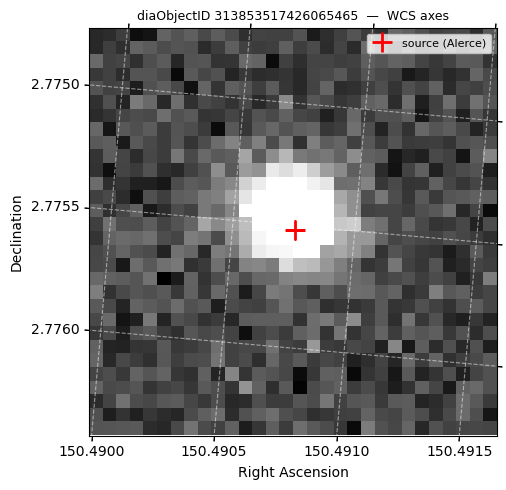

In [10]:
image = ccd.data
wcs   = ccd.wcs

fig = plt.figure(figsize=(5.5, 5))
ax  = fig.add_subplot(111, projection=wcs)

vmin, vmax = zscale.get_limits(image)
ax.imshow(image, origin='lower', cmap='gray',
          vmin=vmin, vmax=vmax, interpolation='nearest')

# Plot source using pixel coords (world_to_pixel_values is safe even when
# wcs is not recognised as a celestial frame by the high-level API)
ax.plot(x_pix, y_pix, 'r+', ms=14, mew=2,
        transform=ax.get_transform('pixel'), label='source (Alerce)')

ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.coords.grid(color='white', linestyle='dashed', alpha=0.5)
ax.set_title(f'diaObjectID {DIA_OBJECT_ID}  —  WCS axes', fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## PSF Characterisation

The PSF kernel can be characterised directly from `ccd.psf`. A 2-D Gaussian fit gives the width in pixels, which converts to arcsec using the pixel scale extracted from the WCS:

In [11]:
pixel_scale_arcsec = np.sqrt(abs(np.linalg.det(wcs.pixel_scale_matrix))) * 3600
psf_arr = np.array(ccd.psf)
ny, nx  = psf_arr.shape
y_grid, x_grid = np.indices((ny, nx))

g_fit = fitting.LevMarLSQFitter()(
    models.Gaussian2D(
        amplitude=psf_arr.max(),
        x_mean=nx/2, y_mean=ny/2,
        x_stddev=2.0, y_stddev=2.0,
    ),
    x_grid, y_grid, psf_arr,
)

sigma_x = abs(g_fit.x_stddev.value)
sigma_y = abs(g_fit.y_stddev.value)
fwhm_px = 2.355 * np.sqrt(sigma_x * sigma_y)
fwhm_as = fwhm_px * pixel_scale_arcsec

print(f'σ_x  = {sigma_x:.3f} px')
print(f'σ_y  = {sigma_y:.3f} px')
print(f'FWHM = {fwhm_px:.3f} px  =  {fwhm_as:.3f} arcsec')
print(f'Pixel scale = {pixel_scale_arcsec:.4f} arcsec/px')

σ_x  = 2.843 px
σ_y  = 2.445 px
FWHM = 6.210 px  =  1.242 arcsec
Pixel scale = 0.2000 arcsec/px


### Plot PSF fit residual

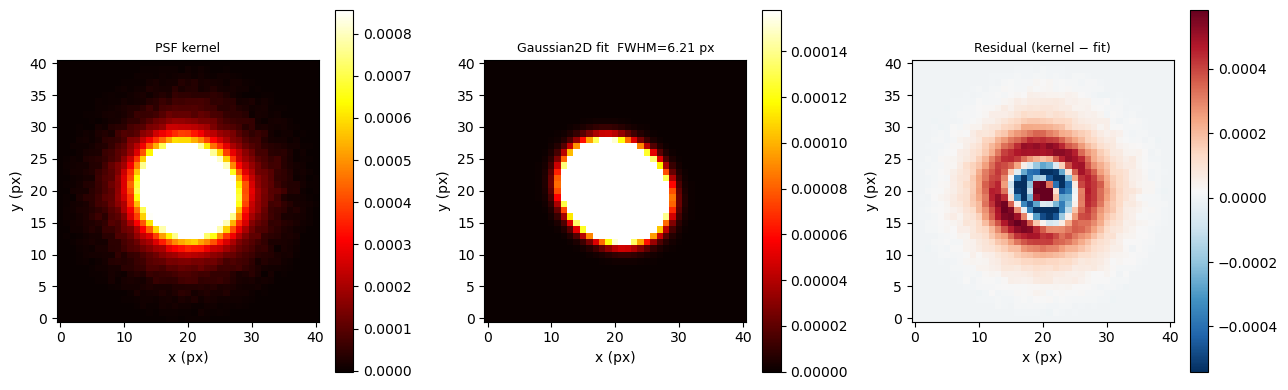

In [12]:
# Visualise fit residual
psf_model = g_fit(x_grid, y_grid)
residual  = psf_arr - psf_model

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title, cmap in [
    (axes[0], psf_arr,   'PSF kernel', 'hot'),
    (axes[1], psf_model, f'Gaussian2D fit  FWHM={fwhm_px:.2f} px', 'hot'),
    (axes[2], residual,  'Residual (kernel − fit)', 'RdBu_r'),
]:
    vmin, vmax = zscale.get_limits(data)
    im = ax.imshow(data, origin='lower', cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

plt.tight_layout()
plt.show()

For typical Rubin seeing (FWHM ≈ 0.7 arcsec) the Gaussian sigma is roughly 1.5 px.

## Forced Photometry with the LSST Science Pipelines

For tasks that need the full measurement framework — forced photometry, aperture corrections, pixel flags — the `CCDData` must be converted to an `lsst.afw.image.ExposureF`. The bridge requires translating the astropy WCS into an LSST `SkyWcs` and wrapping the PSF kernel in a `KernelPsf`.

In [13]:
def ccddata_to_exposureF(ccd):
    """Build an lsst.afw.image.ExposureF from an astropy CCDData object.

    Bridges the astropy → LSST boundary:
      • image data      → afwImage.ImageF
      • variance plane  → afwImage.ImageF  (from VarianceUncertainty)
      • WCS             → makeSkyWcs via crpix / crval / PC × CDELT
      • PSF kernel      → KernelPsf(FixedKernel(ImageD))

    The PSF kernel is trimmed to fit within the image if necessary.
    Alert stamps are 30×30 px but the stored PSF kernel is 41×41 px; without
    trimming, base_PsfFlux sets flag_edge because the PSF image bbox extends
    outside the exposure bbox.
    """
    # ── Image and variance ────────────────────────────────────────────────────
    image    = afwImage.ImageF(ccd.data.astype(np.float32))
    variance = afwImage.ImageF(ccd.uncertainty.array.astype(np.float32))
    mask     = afwImage.MaskX(image.getBBox())   # empty mask plane
    mi       = afwImage.MaskedImageF(image, mask, variance)
    exp      = afwImage.ExposureF(mi)

    # ── WCS ───────────────────────────────────────────────────────────────────
    # astropy stores CRPIX as 1-indexed; LSST uses 0-indexed — subtract 1.
    w = ccd.wcs.wcs
    crpix = lsst_geom.Point2D(w.crpix[0] - 1.0, w.crpix[1] - 1.0)
    crval = lsst_geom.SpherePoint(
        w.crval[0] * lsst_geom.degrees,
        w.crval[1] * lsst_geom.degrees,
    )
    cd = np.diag(w.get_cdelt()) @ w.get_pc()   # degrees per pixel
    exp.setWcs(makeSkyWcs(crpix=crpix, crval=crval, cdMatrix=cd))

    # ── PSF ───────────────────────────────────────────────────────────────────
    psf_arr = np.array(ccd.psf, dtype=np.float64)

    # Trim PSF kernel to fit within the image.  base_PsfFlux checks whether
    # the PSF image bbox is fully contained in the exposure bbox and sets
    # flag_edge if not.  Max safe odd kernel size = image_dim - 2 (1 px margin
    # each side), rounded down to the nearest odd number.
    ny_img, nx_img = ccd.data.shape
    max_dim = min(ny_img - 2, nx_img - 2)
    if max_dim % 2 == 0:
        max_dim -= 1                            # keep odd

    ny, nx = psf_arr.shape
    if ny > max_dim or nx > max_dim:
        cy, cx  = ny // 2, nx // 2
        half    = max_dim // 2
        psf_arr = psf_arr[cy - half : cy + half + 1,
                          cx - half : cx + half + 1]
        psf_arr = psf_arr / psf_arr.sum()       # renormalise after trim
        ny, nx  = psf_arr.shape

    psf_img = afwImage.ImageD(nx, ny)
    psf_img.array[:] = psf_arr
    exp.setPsf(KernelPsf(FixedKernel(psf_img)))

    return exp


exp = ccddata_to_exposureF(ccd)

print('ExposureF built from CCDData:')
print(f'  Dimensions : {exp.getDimensions()}')
crval_pt = exp.getWcs().getSkyOrigin()
print(f'  WCS CRVAL  : RA={crval_pt.getRa().asDegrees():.6f}  '
      f'Dec={crval_pt.getDec().asDegrees():.6f}')
psf_obj = exp.getPsf()
print(f'  PSF type   : {type(psf_obj).__name__}')
k = psf_obj.getKernel()
print(f'  PSF kernel : {k.getWidth()}×{k.getHeight()} px  '
      f'(trimmed from {np.array(ccd.psf).shape[1]}×{np.array(ccd.psf).shape[0]})')

ExposureF built from CCDData:
  Dimensions : (30, 30)
  WCS CRVAL  : RA=150.490757  Dec=2.775519
  PSF type   : KernelPsf
  PSF kernel : 27×27 px  (trimmed from 41×41)


Forced photometry then uses `ForcedMeasurementDriverTask` from `lsst.pipe.tasks.measurementDriver` (not `lsst.meas.base`):

Run the task using the input table of source positions and IDs, the deep_coadd image, and required parameters: column names for ID, RA, and Dec, plus a PSF footprint scaling factor (used to create synthetic footprints since detection is skipped in forced photometry).

In [14]:
# Source sky position — replace with your own RA/Dec and ID
src_ra, src_dec = SRC_RA, SRC_DEC # ccd.wcs.wcs.crval   # WCS centre used as example
source_table = Table({
    'id' : [1],
    'ra' : [src_ra]  * u.deg,
    'dec': [src_dec] * u.deg,
})

config = ForcedMeasurementDriverConfig()
config.measurement.slots.psfFlux  = 'base_PsfFlux'
config.measurement.slots.centroid = 'base_TransformedCentroidFromCoord'
config.measurement.slots.shape    = None
config.measurement.doReplaceWithNoise = False
config.doApCorr = False

In [15]:
driver = ForcedMeasurementDriverTask(config=config)
meas = driver.runFromAstropy(
    source_table, exp,
    id_column_name        = 'id',
    ra_column_name        = 'ra',
    dec_column_name       = 'dec',
    psf_footprint_scaling = 3.0,
)

# Rename instFlux → flux for readability and attach units
for col in [c for c in meas.colnames if 'instFlux' in c]:
    new = col.replace('instFlux', 'flux')
    meas.rename_column(col, new)
    meas[new].unit = u.nJy

INFO:lsst.forcedMeasurementDriver:Measuring 1 sources in a single band using 'ForcedMeasurementTask'
INFO:lsst.forcedMeasurementDriver.measurement:Performing forced measurement on 1 source
INFO:lsst.forcedMeasurementDriver:Finished processing for a single band; output catalog has 85 fields and 1 records


In [16]:
# Results 
flux     = meas['base_PsfFlux_flux'][0]
flux_err = meas['base_PsfFlux_fluxErr'][0]
flag     = meas['base_PsfFlux_flag'][0]
cx       = float(meas['base_TransformedCentroidFromCoord_x'][0])
cy       = float(meas['base_TransformedCentroidFromCoord_y'][0])
snr      = flux / flux_err if flux_err > 0 else float('nan')

print(f'PSF flux     : {flux:.4f} ± {flux_err:.4f} nJy')
print(f'SNR          : {snr:.2f}')
print(f'Failure flag : {flag}')

if  flux > 0:
    ab_mag     = -2.5 * np.log10(flux * 1e-9 / 3631)
    ab_mag_err =  2.5 / np.log(10) * flux_err / flux
    mag_label  = f'{ab_mag:.3f} ± {ab_mag_err:.3f} mag (AB)'
    print(f'AB magnitude : {ab_mag:.4f} ± {ab_mag_err:.4f} mag')
else:
    print('Flux measurement flagged or negative — magnitude not computed.')
    ab_mag = ab_mag_err = None
    mag_label = 'flagged'

PSF flux     : 23554.6931 ± 371.3381 nJy
SNR          : 63.43
Failure flag : False
AB magnitude : 20.4699 ± 0.0171 mag


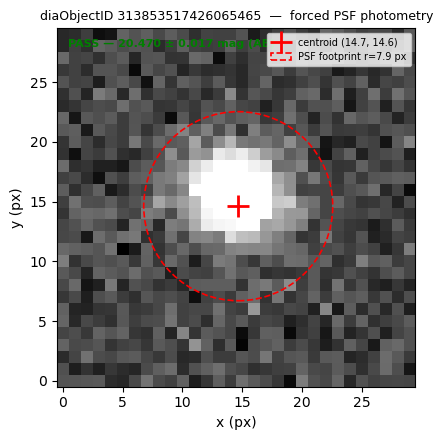

In [17]:
# Figure — science stamp with measured centroid and PSF footprint overlay
fig, ax_img = plt.subplots(1, 1, figsize=(5.5, 4.5))

vmin, vmax = ZScaleInterval().get_limits(ccd.data)
ax_img.imshow(ccd.data, origin='lower', cmap='gray',
              vmin=vmin, vmax=vmax, interpolation='nearest')

psf_sigma_px = fwhm_px / 2.355
footprint_r  = psf_sigma_px * 3.0      # psf_sigma × psf_footprint_scaling

ax_img.plot(cx, cy, 'r+', ms=16, mew=2,
            label=f'centroid ({cx:.1f}, {cy:.1f})')
circle = mpatches.Circle((cx, cy), footprint_r, color='red', fill=False,
                          linewidth=1.2, linestyle='--',
                          label=f'PSF footprint r={footprint_r:.1f} px')
ax_img.add_patch(circle)

ann_color = 'green' if not flag else 'red'
ann_text  = f'PASS — {mag_label}' if not flag else f'FLAGGED — {mag_label}'
ax_img.text(0.03, 0.97, ann_text, transform=ax_img.transAxes,
            fontsize=8, fontweight='bold', color=ann_color,
            va='top', ha='left')

ax_img.set_title(f'diaObjectID {DIA_OBJECT_ID}  —  forced PSF photometry', fontsize=9)
ax_img.set_xlabel('x (px)'); ax_img.set_ylabel('y (px)')
ax_img.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()
